In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# FIXED THERMOCHEMISTRY EVALUATION FROM EXISTING OUTPUT FILES
# ============================================================

DATATYPE = "Thermochemistry"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
I = ROOT / "Info"

values_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
errors_file = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
error_log_file = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_error_log.csv"

standard_file = I / "Standard_errors.csv"
datasets_file = I / "Datasets.csv"

df_val = pd.read_csv(values_file, index_col=0)
df_err = pd.read_csv(errors_file, index_col=0)
df_std = pd.read_csv(standard_file, index_col=0)
df_info = pd.read_csv(datasets_file, index_col=0)

datatype_datasets = df_info.index[df_info["Datatype"] == DATATYPE].tolist()

df_val = df_val[df_val["Dataset"].isin(datatype_datasets)].copy()
df_err = df_err[df_err["Dataset"].isin(datatype_datasets)].copy()

print("Loaded values:", values_file)
print("Loaded errors:", errors_file)
print("Thermochemistry datasets:", len(datatype_datasets))
print("Thermochemistry points:", len(df_val))

if error_log_file.exists():
    df_log = pd.read_csv(error_log_file)
    print("\nMACE error log:")
    print(df_log.to_string(index=False))

# ============================================================
# Strict per-dataset metrics
# Important correction:
# If a model has any missing value inside a dataset, that
# dataset's metric becomes NaN for that model.
# This prevents AE11 from being incorrectly evaluated from 10/11 points.
# ============================================================

rows = []

for dataset, g_val in df_val.groupby("Dataset"):
    g_err = df_err.loc[g_val.index]
    standard_metric = float(df_std.loc[dataset, "Metric"])
    n_total = len(g_val)

    for model in MODELS:
        ref = pd.to_numeric(g_val["Reference"], errors="coerce")
        pred = pd.to_numeric(g_val[model], errors="coerce")
        err = pd.to_numeric(g_err[model], errors="coerce")

        complete = ref.notna().all() and pred.notna().all() and err.notna().all()

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err ** 2)))
            metric = mae    # Thermochemistry default Metric = MAE in analyze.ipynb
            ner = metric / standard_metric
            status = "COMPLETE"
            n_used = n_total
        else:
            mae = np.nan
            rmse = np.nan
            metric = np.nan
            ner = np.nan
            status = "INCOMPLETE"
            n_used = int((ref.notna() & pred.notna()).sum())

        rows.append({
            "Dataset": dataset,
            "Datatype": DATATYPE,
            "Model": model,
            "Label": LABELS[model],
            "Unit": UNIT,
            "N_total": n_total,
            "N_used": n_used,
            "Status": status,
            "Standard_Error_Metric": standard_metric,
            "MAE": mae,
            "RMSE": rmse,
            "Metric_Error": metric,
            "NER": ner,
        })

df_set = pd.DataFrame(rows)

# Save strict long table
strict_long_out = A / f"{TAG}_MACE_POLAR_FIXED_STRICT_per_set_metrics_long.csv"
df_set.to_csv(strict_long_out, index=False)

# Save wide NER table
df_ner_wide = df_set.pivot(index="Dataset", columns="Model", values="NER")
df_ner_wide.insert(0, "Datatype", DATATYPE)
ner_wide_out = A / f"{TAG}_MACE_POLAR_FIXED_STRICT_NER_per_set.csv"
df_ner_wide.to_csv(ner_wide_out)

# Save wide MAE and RMSE tables
df_mae_wide = df_set.pivot(index="Dataset", columns="Model", values="MAE")
df_rmse_wide = df_set.pivot(index="Dataset", columns="Model", values="RMSE")

mae_wide_out = A / f"{TAG}_MACE_POLAR_FIXED_STRICT_MAE_per_set.csv"
rmse_wide_out = A / f"{TAG}_MACE_POLAR_FIXED_STRICT_RMSE_per_set.csv"

df_mae_wide.to_csv(mae_wide_out)
df_rmse_wide.to_csv(rmse_wide_out)

# ============================================================
# Datatype summary
# ============================================================

summary_rows = []

for model in MODELS:
    sub = df_set[df_set["Model"] == model].copy()

    # Strict MRE/NER: equal-weight mean across COMPLETE datasets only.
    mre = sub["NER"].mean(skipna=True)

    mean_set_mae = sub["MAE"].mean(skipna=True)
    mean_set_rmse = sub["RMSE"].mean(skipna=True)

    complete_datasets = int((sub["Status"] == "COMPLETE").sum())
    incomplete_datasets = int((sub["Status"] == "INCOMPLETE").sum())

    # Pooled pointwise metrics are descriptive only.
    valid = df_val[["Reference", model]].dropna()
    x = pd.to_numeric(valid["Reference"], errors="coerce")
    y = pd.to_numeric(valid[model], errors="coerce")
    e = y - x

    pooled_mae = float(np.mean(np.abs(e)))
    pooled_rmse = float(np.sqrt(np.mean(e ** 2)))
    pearson_r = float(np.corrcoef(x, y)[0, 1]) if len(valid) > 1 else np.nan

    summary_rows.append({
        "Datatype": DATATYPE,
        "Model": model,
        "Label": LABELS[model],
        "Unit": UNIT,
        "Complete_Datasets": complete_datasets,
        "Incomplete_Datasets": incomplete_datasets,
        "Total_Datasets": complete_datasets + incomplete_datasets,
        "Mean_Per_Set_MAE": mean_set_mae,
        "Mean_Per_Set_RMSE": mean_set_rmse,
        "Mean_Relative_Error_NER": mre,
        "Pooled_Pointwise_MAE": pooled_mae,
        "Pooled_Pointwise_RMSE": pooled_rmse,
        "Pooled_Pointwise_Pearson_r": pearson_r,
    })

df_summary = pd.DataFrame(summary_rows)

summary_out = A / f"{TAG}_MACE_POLAR_FIXED_STRICT_Datatype_Summary.csv"
df_summary.to_csv(summary_out, index=False)

print("\nFixed strict datatype summary:")
print(df_summary.to_string(index=False))

print("\nWorst dataset-level NER values:")
for model in MODELS:
    print("\n", LABELS[model])
    print(
        df_set[df_set["Model"] == model]
        .sort_values("NER", ascending=False)
        [["Dataset", "Status", "N_used", "N_total", "MAE", "Standard_Error_Metric", "NER"]]
        .head(12)
        .to_string(index=False)
    )

print("\nSaved fixed files:")
for f in [strict_long_out, ner_wide_out, mae_wide_out, rmse_wide_out, summary_out]:
    print(f)

Loaded values: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Results_values_with_MACE_POLAR_Datatype_Thermochemistry_ALL3.csv
Loaded errors: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Results_errors_with_MACE_POLAR_Datatype_Thermochemistry_ALL3.csv
Thermochemistry datasets: 44
Thermochemistry points: 1971

MACE error log:
Molecule          Model                                     Error
 AE11_Rn mace-polar-1-s ValueError('np.int64(86) is not in list')
 AE11_Rn mace-polar-1-m ValueError('np.int64(86) is not in list')
 AE11_Rn mace-polar-1-l ValueError('np.int64(86) is not in list')

Fixed strict datatype summary:
       Datatype          Model          Label     Unit  Complete_Datasets  Incomplete_Datasets  Total_Datasets  Mean_Per_Set_MAE  Mean_Per_Set_RMSE  Mean_Relative_Error_NER  Pooled_Pointwise_MAE  Pooled_Pointwise_RMSE  Pooled_Pointwise_Pearson_r
Thermochemistry        wB97M-V        wB97M-V kcal/mol                 44                    0             

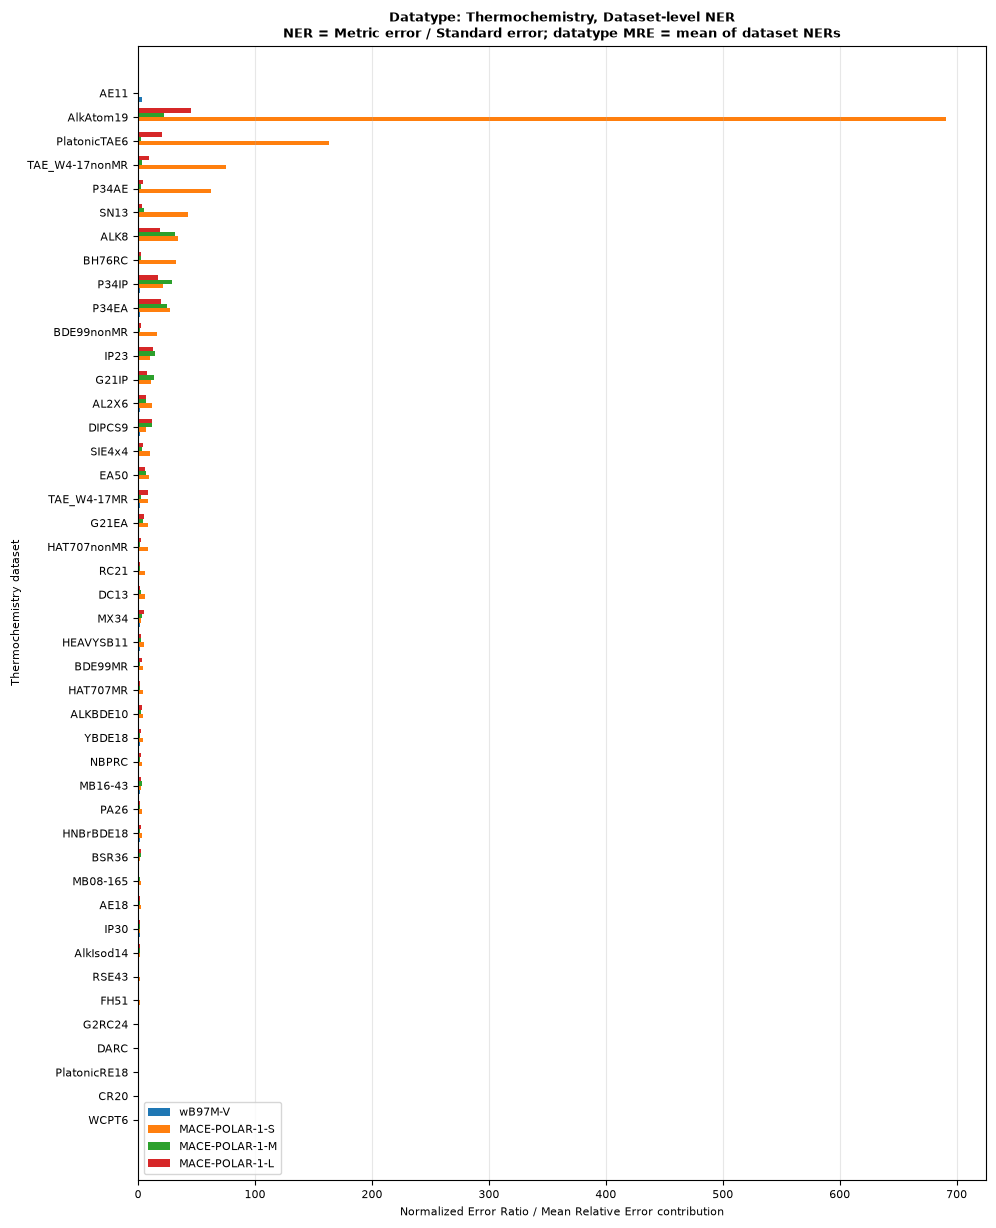

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Thermochemistry_FIXED_dataset_level_NER_all_datasets.png

Correlation plot filtering:
Dropped datasets: ['AE11', 'AE18']
Error cutoff: 100.0
Plotted points: 1764
Plotted datasets: 40
Datasets included:
['AL2X6', 'ALK8', 'ALKBDE10', 'AlkIsod14', 'BDE99MR', 'BDE99nonMR', 'BH76RC', 'BSR36', 'CR20', 'DARC', 'DC13', 'DIPCS9', 'EA50', 'FH51', 'G21EA', 'G21IP', 'G2RC24', 'HAT707MR', 'HAT707nonMR', 'HEAVYSB11', 'HNBrBDE18', 'IP23', 'IP30', 'MB08-165', 'MB16-43', 'MX34', 'NBPRC', 'P34AE', 'P34EA', 'P34IP', 'PA26', 'PlatonicRE18', 'RC21', 'RSE43', 'SIE4x4', 'SN13', 'TAE_W4-17MR', 'TAE_W4-17nonMR', 'WCPT6', 'YBDE18']
Saved plotted-point table: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Thermochemistry_FIXED_correlation_plot_points.csv


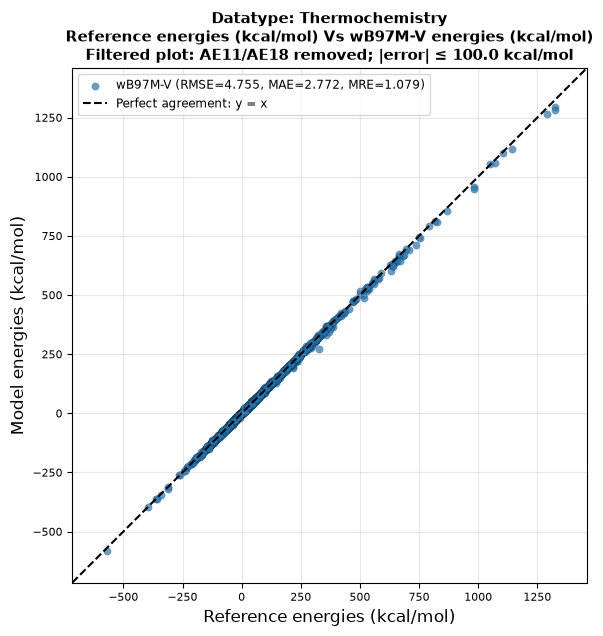

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Thermochemistry_FIXED_Reference_vs_wB97M-V_filtered_RMSE_MAE_MRE.png


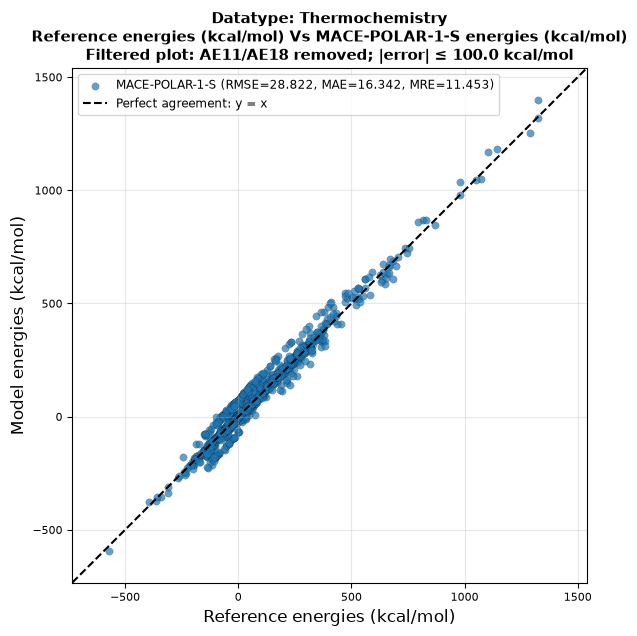

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Thermochemistry_FIXED_Reference_vs_mace-polar-1-s_filtered_RMSE_MAE_MRE.png


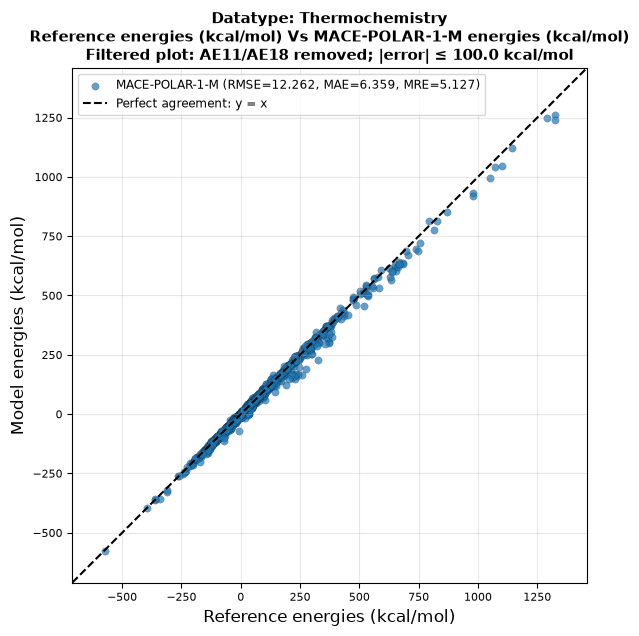

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Thermochemistry_FIXED_Reference_vs_mace-polar-1-m_filtered_RMSE_MAE_MRE.png


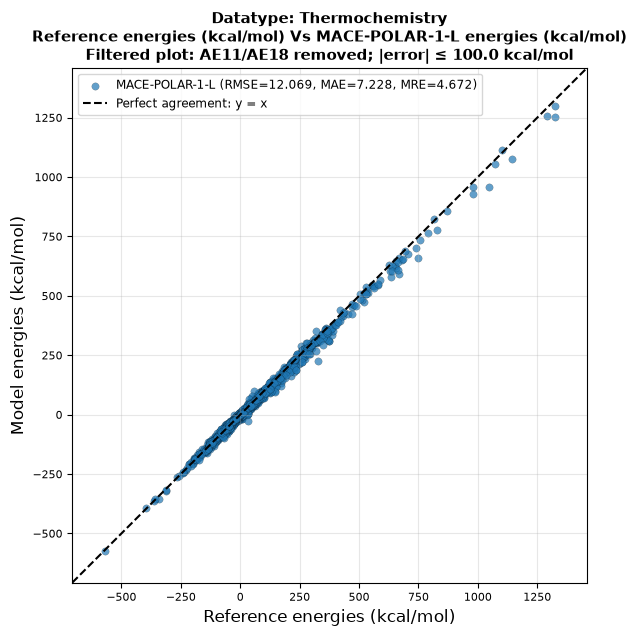

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Thermochemistry_FIXED_Reference_vs_mace-polar-1-l_filtered_RMSE_MAE_MRE.png


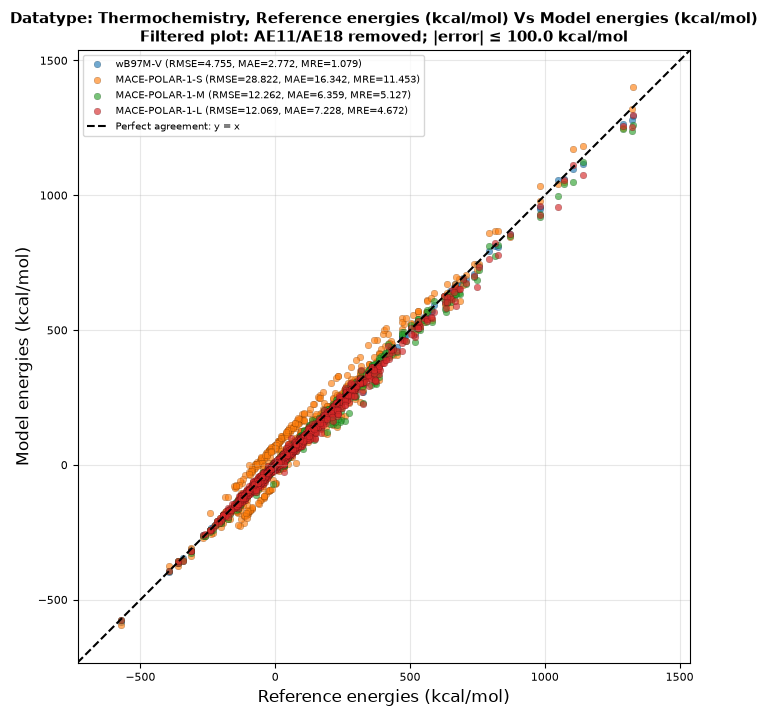

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Thermochemistry_FIXED_all_models_filtered_RMSE_MAE_MRE.png

Saved plot metrics:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Thermochemistry_FIXED_correlation_plot_metrics_RMSE_MAE_MRE.csv
       Datatype          Model     Unit  Plotted_Points  Plotted_RMSE  Plotted_MAE  Plotted_Pearson_r  MRE_NER_for_Plotted_Datasets
Thermochemistry        wB97M-V kcal/mol            1764      4.754765     2.771714           0.999675                      1.078759
Thermochemistry MACE-POLAR-1-S kcal/mol            1764     28.821757    16.341568           0.986855                     11.453078
Thermochemistry MACE-POLAR-1-M kcal/mol            1764     12.262412     6.359285           0.997806                      5.127332
Thermochemistry MACE-POLAR-1-L kcal/mol            1764     12.068815     7.227886           0.998225                      4.671785


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FIXED THERMOCHEMISTRY PLOTS
# ============================================================

DATATYPE = "Thermochemistry"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
set_metric_file = A / f"{TAG}_MACE_POLAR_FIXED_STRICT_per_set_metrics_long.csv"

df_val = pd.read_csv(val_file, index_col=0)
df_set = pd.read_csv(set_metric_file)

# ============================================================
# 1. Dataset-level NER plot
# ============================================================

ner = df_set.pivot(index="Dataset", columns="Model", values="NER")
ner = ner[MODELS]

# Put worst datasets at top according to max MACE NER
ner_for_order = ner[["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]].max(axis=1)
ordered = ner.loc[ner_for_order.sort_values(ascending=True).index]

plt.figure(figsize=(10, max(8, 0.28 * len(ordered))))

y = np.arange(len(ordered))
bar_h = 0.18

for i, model in enumerate(MODELS):
    plt.barh(
        y + (i - 1.5) * bar_h,
        ordered[model],
        height=bar_h,
        label=LABELS[model],
    )

plt.yticks(y, ordered.index)
plt.xlabel("Normalized Error Ratio / Mean Relative Error contribution")
plt.ylabel("Thermochemistry dataset")
plt.title(
    "Datatype: Thermochemistry, Dataset-level NER\n"
    "NER = Metric error / Standard error; datatype MRE = mean of dataset NERs",
    fontweight="bold",
)
plt.grid(axis="x", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

out = FIG / f"{TAG}_FIXED_dataset_level_NER_all_datasets.png"
plt.savefig(out, dpi=300)
plt.show()
print("Saved:", out)

# ============================================================
# 2. Cleaned correlation plot
# ============================================================
# Why filtering is needed:
# - AE11 has unsupported Rn and massive absolute atomic energies.
# - AE18 also has huge absolute atomic energies.
# - Optional error cutoff prevents a few extreme MLIP failures from destroying the axis scale.
# This plot is for visual interpretation only.
# Official MRE/NER should be taken from the strict summary table.
# ============================================================

DROP_DATASETS_FOR_CORRELATION = ["AE11", "AE18"]
ERROR_CUTOFF_FOR_PLOT = 100.0   # kcal/mol. Set to None if you want no error filtering.

plot_df = df_val.copy()
plot_df = plot_df[~plot_df["Dataset"].isin(DROP_DATASETS_FOR_CORRELATION)].copy()
plot_df = plot_df.dropna(subset=["Reference"] + MODELS).copy()

if ERROR_CUTOFF_FOR_PLOT is not None:
    mask = np.ones(len(plot_df), dtype=bool)
    for model in MODELS:
        mask &= (pd.to_numeric(plot_df[model], errors="coerce") - pd.to_numeric(plot_df["Reference"], errors="coerce")).abs() <= ERROR_CUTOFF_FOR_PLOT
    plot_df = plot_df.loc[mask].copy()

print("\nCorrelation plot filtering:")
print("Dropped datasets:", DROP_DATASETS_FOR_CORRELATION)
print("Error cutoff:", ERROR_CUTOFF_FOR_PLOT)
print("Plotted points:", len(plot_df))
print("Plotted datasets:", plot_df["Dataset"].nunique())
print("Datasets included:")
print(sorted(plot_df["Dataset"].unique()))

plot_points_out = A / f"{TAG}_FIXED_correlation_plot_points.csv"
plot_df.to_csv(plot_points_out)
print("Saved plotted-point table:", plot_points_out)

def metrics_on_points(df, model):
    d = df[["Reference", model]].dropna()
    x = pd.to_numeric(d["Reference"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(d[model], errors="coerce").to_numpy(float)
    e = y - x
    return {
        "N": len(x),
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "MAE": float(np.mean(np.abs(e))),
        "Pearson_r": float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan,
    }

def mre_for_plotted_datasets(model):
    datasets = sorted(plot_df["Dataset"].unique())
    sub = df_set[
        (df_set["Model"] == model)
        & (df_set["Dataset"].isin(datasets))
        & (df_set["Status"] == "COMPLETE")
    ]
    return float(sub["NER"].mean(skipna=True))

def plot_limits(df, models):
    values = [pd.to_numeric(df["Reference"], errors="coerce").dropna().to_numpy(float)]
    for model in models:
        values.append(pd.to_numeric(df[model], errors="coerce").dropna().to_numpy(float))
    v = np.concatenate(values)
    pad = 0.07 * (v.max() - v.min())
    return v.min() - pad, v.max() + pad

# Individual plots
plot_metric_rows = []

for model in MODELS:
    m = metrics_on_points(plot_df, model)
    mre = mre_for_plotted_datasets(model)

    plot_metric_rows.append({
        "Datatype": DATATYPE,
        "Model": LABELS[model],
        "Unit": UNIT,
        "Plotted_Points": m["N"],
        "Plotted_RMSE": m["RMSE"],
        "Plotted_MAE": m["MAE"],
        "Plotted_Pearson_r": m["Pearson_r"],
        "MRE_NER_for_Plotted_Datasets": mre,
    })

    lo, hi = plot_limits(plot_df, [model])

    plt.figure(figsize=(7.0, 6.4))

    plt.scatter(
        plot_df["Reference"],
        plot_df[model],
        s=28,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.15,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

    plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5, label="Perfect agreement: y = x")

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("Reference energies (kcal/mol)", fontsize=12)
    plt.ylabel("Model energies (kcal/mol)", fontsize=12)

    plt.title(
        f"Datatype: Thermochemistry\n"
        f"Reference energies (kcal/mol) Vs {LABELS[model]} energies (kcal/mol)\n"
        f"Filtered plot: AE11/AE18 removed; |error| ≤ {ERROR_CUTOFF_FOR_PLOT} kcal/mol",
        fontsize=11,
        fontweight="bold",
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=8.5)
    plt.tight_layout()

    out = FIG / f"{TAG}_FIXED_Reference_vs_{model}_filtered_RMSE_MAE_MRE.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved:", out)

# Combined all-model plot
lo, hi = plot_limits(plot_df, MODELS)

plt.figure(figsize=(7.8, 7.2))

for model in MODELS:
    m = metrics_on_points(plot_df, model)
    mre = mre_for_plotted_datasets(model)

    plt.scatter(
        plot_df["Reference"],
        plot_df[model],
        s=24,
        alpha=0.64,
        edgecolors="black",
        linewidths=0.15,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5, label="Perfect agreement: y = x")

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference energies (kcal/mol)", fontsize=12)
plt.ylabel("Model energies (kcal/mol)", fontsize=12)

plt.title(
    "Datatype: Thermochemistry, Reference energies (kcal/mol) Vs Model energies (kcal/mol)\n"
    f"Filtered plot: AE11/AE18 removed; |error| ≤ {ERROR_CUTOFF_FOR_PLOT} kcal/mol",
    fontsize=11,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=7.4)
plt.tight_layout()

out = FIG / f"{TAG}_FIXED_all_models_filtered_RMSE_MAE_MRE.png"
plt.savefig(out, dpi=300)
plt.show()
print("Saved:", out)

plot_metrics = pd.DataFrame(plot_metric_rows)
plot_metrics_out = A / f"{TAG}_FIXED_correlation_plot_metrics_RMSE_MAE_MRE.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)
print(plot_metrics.to_string(index=False))